In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
# Create a simple dataset

data = {
    "Size": [800, 900, 1000, 1100, 1200, 1500, 1600, 1700],
    "Rooms": [2, 2, 3, 3, 3, 4, 4, 5],
    "Age": [20, 15, 18, 10, 8, 5, 7, 3],
    "Distance": [10, 12, 9, 7, 6, 4, 3, 2],
    "Price": [80, 85, 90, 120, 130, 160, 170, 200]
}

df = pd.DataFrame(data)
df


,Size,Rooms,Age,Distance,Price
0,800,2,20,10,80
1,900,2,15,12,85
2,1000,3,18,9,90
3,1100,3,10,7,120
4,1200,3,8,6,130
5,1500,4,5,4,160
6,1600,4,7,3,170
7,1700,5,3,2,200


# Explain 
- Larger size → higher price
- Less distance → higher price
- Newer houses → costly


In [3]:
# Features (X) and Target (y)

X = df[["Size", "Rooms", "Age", "Distance"]]
y = df["Price"]

In [4]:
# Create model
model = DecisionTreeRegressor(max_depth=3, random_state=42)

# Train model
model.fit(X, y)

# Explain:
# max_depth=3 → keeps tree small for visualization
# Tree learns rules, not equations.


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [5]:
# Predict price of a new house
new_house = [[1400, 3, 6, 5]]
# convert it to DF
new_house_df = pd.DataFrame(new_house, columns=X.columns) 

predicted_price = model.predict(new_house_df)

print("Predicted Price:", predicted_price[0])


Predicted Price: 160.0


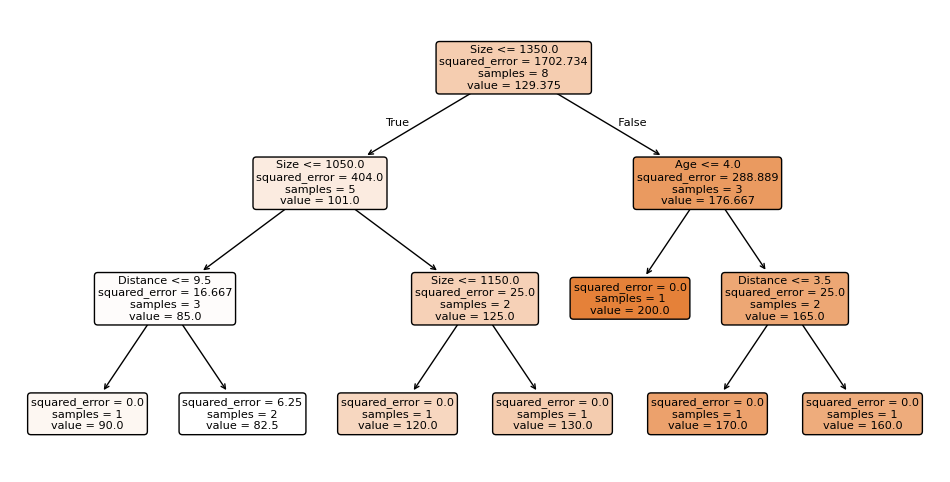

In [6]:

plt.figure(figsize=(12,6), ) 

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

In [ ]:
# Analysis

In [7]:
# size < 1350

df[df['Size'] <=1350]

,Size,Rooms,Age,Distance,Price
0,800,2,20,10,80
1,900,2,15,12,85
2,1000,3,18,9,90
3,1100,3,10,7,120
4,1200,3,8,6,130


In [8]:
df[df['Size']  > 1350]

,Size,Rooms,Age,Distance,Price
5,1500,4,5,4,160
6,1600,4,7,3,170
7,1700,5,3,2,200


In [14]:
# size <= 1350 and size <= 1050 

df[(df['Size'] <= 1350) &
    (df['Size'] <= 1050)]

,Size,Rooms,Age,Distance,Price
0,800,2,20,10,80
1,900,2,15,12,85
2,1000,3,18,9,90


In [15]:
# size <= 1350 and size > 1050 

df[(df['Size'] <= 1350) &
    (df['Size'] > 1050)]

,Size,Rooms,Age,Distance,Price
3,1100,3,10,7,120
4,1200,3,8,6,130


In [17]:
# size <= 1350 and size <= 1050 

df[(df['Size'] <= 1350) &
    (df['Size'] <= 1050) &
    (df['Distance'] <= 9.5)
]


,Size,Rooms,Age,Distance,Price
2,1000,3,18,9,90
